In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

df = pd.read_csv('../scraping/data/encoded.csv')

display(df.head())
display(df.info())

,fiyat,metrekare_brut,metrekare_net,bina_yasi,kat,kat_sayisi,banyo_sayisi,ilce,mahalle,kat_orani,...,isitma_Klima,isitma_Kombi,isitma_Kombi Doğalgaz,isitma_Merkezi,isitma_Merkezi (Pay Öl...,isitma_Merkezi (Pay Ölçer),isitma_Merkezi Doğalgaz,isitma_Soba,isitma_VRV,isitma_Yerden Isıtma
0,10450000.0,120.0,105.0,25.0,3.0,4.0,1.0,7.737870e+06,7.790845e+06,0.750000,...,0,0,1,0,0,0,0,0,0,0
1,7599000.0,120.0,100.0,7.5,2.0,5.0,1.0,7.391275e+06,7.329623e+06,0.400000,...,0,0,1,0,0,0,0,0,0,0
2,4450000.0,120.0,115.0,7.5,1.0,4.0,1.0,7.100478e+06,6.668028e+06,0.250000,...,0,0,0,0,0,0,0,0,0,0
3,5750000.0,120.0,115.0,0.0,2.0,4.0,2.0,7.100478e+06,6.668028e+06,0.500000,...,0,0,0,0,0,0,0,0,0,0
4,8500000.0,115.0,95.0,25.0,6.0,11.0,1.0,7.100478e+06,6.778087e+06,0.545455,...,0,0,1,0,0,0,0,0,0,0


<class 'pandas.DataFrame'>
RangeIndex: 12127 entries, 0 to 12126
Data columns (total 30 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   fiyat                       12127 non-null  float64
 1   metrekare_brut              12127 non-null  float64
 2   metrekare_net               12127 non-null  float64
 3   bina_yasi                   12127 non-null  float64
 4   kat                         12127 non-null  float64
 5   kat_sayisi                  12127 non-null  float64
 6   banyo_sayisi                12127 non-null  float64
 7   ilce                        12127 non-null  float64
 8   mahalle                     12127 non-null  float64
 9   kat_orani                   12127 non-null  float64
 10  metrekare_farki             12127 non-null  float64
 11  metrekare_verimliligi       12127 non-null  float64
 12  oda_sayisi                  12127 non-null  float64
 13  salon_sayisi                12127 non-null

None

In [ ]:
X = df.drop('fiyat', axis=1)
y = df['fiyat'].values.reshape(-1, 1)

# Eğitim ve test setlerine ayırma
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# X için Scaler
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

# y için Scaler
scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train)
y_test_scaled = scaler_y.transform(y_test)

# İyi Model 1) Resnet

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization, Add
from tensorflow.keras.models import Model
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Girdi Boyutu (29 özellik)
input_dim = X_train_scaled.shape[1]

# Regularization
l2_reg = l2(1e-4)

# 1. GİRDİ KATMANI
inputs = Input(shape=(input_dim,))

x = Dense(256, kernel_initializer='he_normal', kernel_regularizer=l2_reg, activation='swish')(inputs)
x = BatchNormalization()(x)
x = Dropout(0.2)(x)

shortcut_1 = x 

x = Dense(256, kernel_initializer='he_normal', kernel_regularizer=l2_reg, activation='swish')(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)

x = Dense(256, kernel_initializer='he_normal', kernel_regularizer=l2_reg, activation='swish')(x)
x = BatchNormalization()(x)

x = Add()([x, shortcut_1]) 
x = Dropout(0.2)(x)

shortcut_2 = x 

x = Dense(256, kernel_initializer='he_normal', kernel_regularizer=l2_reg, activation='swish')(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)

x = Dense(256, kernel_initializer='he_normal', kernel_regularizer=l2_reg, activation='swish')(x)
x = BatchNormalization()(x)

x = Add()([x, shortcut_2])
x = Dropout(0.2)(x)

x = Dense(128, kernel_initializer='he_normal', kernel_regularizer=l2_reg, activation='swish')(x)
x = BatchNormalization()(x)
x = Dropout(0.2)(x)

x = Dense(64, kernel_initializer='he_normal', kernel_regularizer=l2_reg, activation='swish')(x)
x = BatchNormalization()(x)

# ÇIKIŞ KATMANI
outputs = Dense(1, kernel_initializer='he_normal')(x)

model = Model(inputs=inputs, outputs=outputs, name="Advanced_ResNet_Model")

model.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate=1e-3, weight_decay=1e-4), 
    loss='huber', 
    metrics=['mae']
)

model.summary()

Model: "Advanced_ResNet_Model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 29)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_14 (Dense)    │ (None, 256)       │      7,680 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256)       │      1,024 │ dense_14[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_10          │ (None, 256)       │          0 │ batch_normalizat… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_15 (Dense)    │ (None, 256)       │     65,792 │ dropout_10[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256)       │      1,024 │ dense_15[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_11          │ (None, 256)       │          0 │ batch_normalizat… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_16 (Dense)    │ (None, 256)       │     65,792 │ dropout_11[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256)       │      1,024 │ dense_16[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 256)       │          0 │ batch_normalizat… │
│                     │                   │            │ dropout_10[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_12          │ (None, 256)       │          0 │ add_3[0][0]       │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_17 (Dense)    │ (None, 256)       │     65,792 │ dropout_12[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256)       │      1,024 │ dense_17[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_13          │ (None, 256)       │          0 │ batch_normalizat… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_18 (Dense)    │ (None, 256)       │     65,792 │ dropout_13[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256)       │      1,024 │ dense_18[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_4 (Add)         │ (None, 256)       │          0 │ batch_normalizat… │
│                     │                   │            │ dropout_12[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_14          │ (None, 256)       │          0 │ add_4[0][0]       │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 317,953 (1.21 MB)

 Trainable params: 315,009 (1.20 MB)

 Non-trainable params: 2,944 (11.50 KB)

In [ ]:
# Callbacks 
lr_reducer = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=12, min_lr=1e-6, verbose=1)
early_stop = EarlyStopping(monitor='val_loss', patience=45, restore_best_weights=True, verbose=1)

# Eğitimi Başlatma
history = model.fit(
    X_train_scaled, y_train_scaled, 
    validation_data=(X_test_scaled, y_test_scaled),
    epochs=100, 
    batch_size=128, 
    callbacks=[early_stop, lr_reducer],
    verbose=1
)

Epoch 1/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.7213 - mae: 0.7954 - val_loss: 0.5611 - val_mae: 0.5988 - learning_rate: 0.0010
Epoch 2/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.5929 - mae: 0.6475 - val_loss: 0.5413 - val_mae: 0.5779 - learning_rate: 0.0010
Epoch 3/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.5655 - mae: 0.6204 - val_loss: 0.5159 - val_mae: 0.5561 - learning_rate: 0.0010
Epoch 4/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.5448 - mae: 0.6018 - val_loss: 0.5094 - val_mae: 0.5633 - learning_rate: 0.0010
Epoch 5/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.5300 - mae: 0.5904 - val_loss: 0.4979 - val_mae: 0.5500 - learning_rate: 0.0010
Epoch 6/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.5148 - mae: 0.5806 - val_loss: 0.4931 - val_mae: 0.5624 - learning_rate: 0.0010
Epoch 7/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.5048 - mae: 0.5777 - val_loss: 0.4831 - val_mae: 0.5586 - learning_rate: 0.0010
Epoch 

In [ ]:
# Modelden tahmin alma (Bu tahminler ölçeklenmiş değerlerdir)
y_pred_scaled = model.predict(X_test_scaled)

# Ölçeklenmiş tahminleri ve test değerlerini gerçek fiyat aralığına geri çevirme (Inverse Transform)
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_test_real = scaler_y.inverse_transform(y_test_scaled)

# R2 ve diğer hata metrikleri
r2 = r2_score(y_test_real, y_pred)
mae = mean_absolute_error(y_test_real, y_pred)
rmse = np.sqrt(mean_squared_error(y_test_real, y_pred))

print(f"Test R2 Skoru: {r2:.4f}")
print(f"Test Ortalama Mutlak Hata (MAE): {mae:,.2f} TL")
print(f"Test Kök Ortalama Kare Hata (RMSE): {rmse:,.2f} TL")

76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Test R2 Skoru: 0.4924
Test Ortalama Mutlak Hata (MAE): 936,591.32 TL
Test Kök Ortalama Kare Hata (RMSE): 1,249,802.46 TL


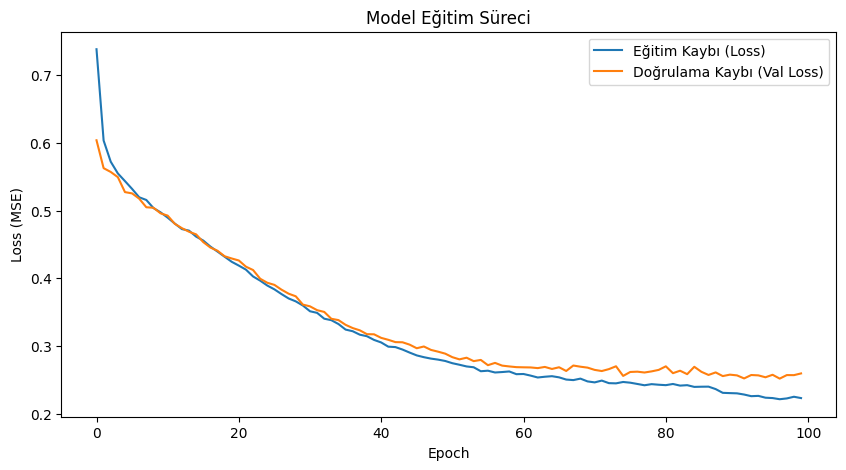

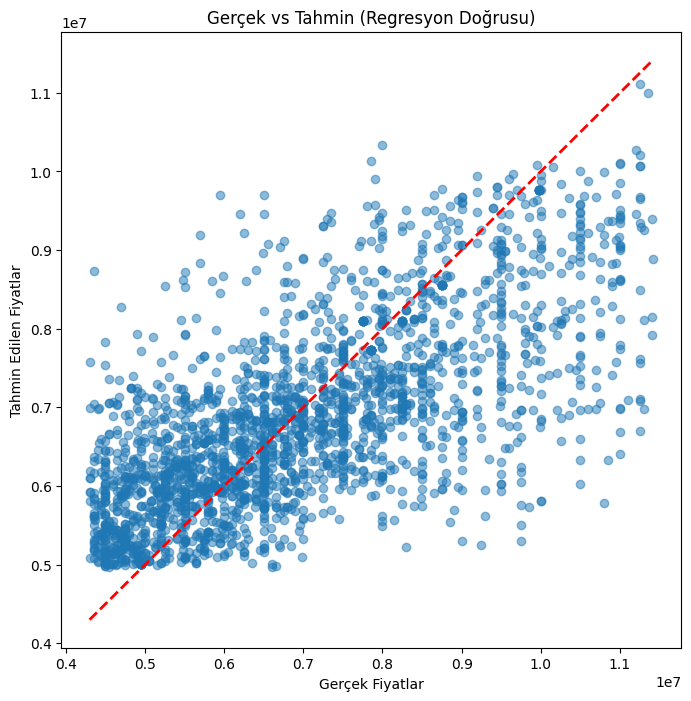

In [12]:
# Loss (Kayıp) grafiği
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Eğitim Kaybı (Loss)')
plt.plot(history.history['val_loss'], label='Doğrulama Kaybı (Val Loss)')
plt.title('Model Eğitim Süreci')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.show()

# Gerçek Fiyatlar vs Tahmin Edilen Fiyatlar Grafiği
plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Gerçek Fiyatlar')
plt.ylabel('Tahmin Edilen Fiyatlar')
plt.title('Gerçek vs Tahmin (Regresyon Doğrusu)')
plt.show()

In [13]:
import os
import joblib
import shutil
from pathlib import Path

# 1. Kaydedilecek yeni sıralı model klasörünü belirleme (model_0, model_1, model_2...)
models_base_dir = Path('../backend/ml-infra/models')
models_base_dir.mkdir(parents=True, exist_ok=True)

# Mevcut model_? klasörlerini tara ve en büyük numarayı bul
existing_models = [d.name for d in models_base_dir.iterdir() if d.is_dir() and d.name.startswith('model_')]
model_nums = []
for name in existing_models:
    try:
        model_nums.append(int(name.split('_')[1]))
    except ValueError:
        pass

next_model_num = max(model_nums) + 1 if model_nums else 0
new_model_dir = models_base_dir / f"model_{next_model_num}"
new_model_dir.mkdir(parents=True, exist_ok=True)
print(f"Yeni model dosyaları '{new_model_dir}' dizinine kaydediliyor...\n")

# 2. Keras modelini kaydetme (.keras formatı)
model.save(new_model_dir / 'model.keras')
print("- model.keras başarıyla kaydedildi.")

# 3. Scaler'ları kaydetme
joblib.dump(scaler_X, new_model_dir / 'scaler_X.pkl')
print("- scaler_X.pkl başarıyla kaydedildi.")

joblib.dump(scaler_y, new_model_dir / 'scaler_y.pkl')
print("- scaler_y.pkl başarıyla kaydedildi.")

# 4. Isıtma (One-Hot) kolon listesini kaydetme (Inference sırasında dinamik eşleme için)
isitma_cols = [col for col in X.columns if col.startswith('isitma_')]
joblib.dump(isitma_cols, new_model_dir / 'isitma_columns.pkl')
print("- isitma_columns.pkl başarıyla kaydedildi.")

# 5. Adım 4'te kaydettiğimiz target_encoder.pkl dosyasını yeni klasöre kopyalama
src_encoder = Path('../scraping/data/target_encoder.pkl')
dst_encoder = new_model_dir / 'target_encoder.pkl'

if src_encoder.exists():
    shutil.copy(src_encoder, dst_encoder)
    print("- target_encoder.pkl başarıyla kopyalandı.")
else:
    print("[UYARI] '../scraping/data/target_encoder.pkl' bulunamadı! Lütfen önce 4)Encoding.ipynb dosyasını çalıştırın.")

print(f"\n[BAŞARILI] Tüm entegrasyon dosyaları 'model_{next_model_num}' klasörüne eksiksiz kaydedildi!")

Yeni model dosyaları '..\backend\ml-infra\models\model_0' dizinine kaydediliyor...

- model.keras başarıyla kaydedildi.
- scaler_X.pkl başarıyla kaydedildi.
- scaler_y.pkl başarıyla kaydedildi.
- isitma_columns.pkl başarıyla kaydedildi.
- target_encoder.pkl başarıyla kopyalandı.

[BAŞARILI] Tüm entegrasyon dosyaları 'model_0' klasörüne eksiksiz kaydedildi!


# İyi model 2)

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, BatchNormalization, Activation
from tensorflow.keras.models import Model
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Girdi Boyutu (29 özellik)
input_dim = X_train_scaled.shape[1]

# Regularization
l2_reg = l2(1e-4)

# 1. GİRDİ KATMANI
inputs = Input(shape=(input_dim,))

x = Dense(256, kernel_initializer='he_normal', kernel_regularizer=l2_reg)(inputs)
x = BatchNormalization()(x)
x = Activation('relu')(x)

x = Dense(256, kernel_initializer='he_normal', kernel_regularizer=l2_reg)(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)

x = Dense(256, kernel_initializer='he_normal', kernel_regularizer=l2_reg)(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)

x = Dense(256, kernel_initializer='he_normal', kernel_regularizer=l2_reg)(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)

x = Dense(256, kernel_initializer='he_normal', kernel_regularizer=l2_reg)(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)

x = Dense(128, kernel_initializer='he_normal', kernel_regularizer=l2_reg)(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)

x = Dense(32, kernel_initializer='he_normal', kernel_regularizer=l2_reg)(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)

# ÇIKIŞ KATMANI (Regresyon)
outputs = Dense(1, kernel_initializer='he_normal')(x)

# Model Tanımı
model = Model(inputs=inputs, outputs=outputs, name="Standard_Sequential_Dense_Model")

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3), 
    loss='huber', 
    metrics=['mae']
)

model.summary()

Model: "Standard_Sequential_Dense_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 29)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 256)            │         7,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_31          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_32          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_33          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_9 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_34          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_10 (Activation)      │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_35          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_11 (Activation)      │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_36          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_12 (Activation)      │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_37          │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 313,665 (1.20 MB)

 Trainable params: 310,785 (1.19 MB)

 Non-trainable params: 2,880 (11.25 KB)

In [ ]:
# --- CALLBACKS ---
lr_reducer = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=8, min_lr=1e-6, verbose=1)
early_stop = EarlyStopping(monitor='val_loss', patience=30, restore_best_weights=True, verbose=1)

# Eğitimi Başlatma
history = model.fit(
    X_train_scaled, y_train_scaled, 
    validation_data=(X_test_scaled, y_test_scaled),
    epochs=100, 
    batch_size=128, 
    callbacks=[early_stop, lr_reducer],
    verbose=1
)

Epoch 1/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 0.6006 - mae: 0.6500 - val_loss: 0.6016 - val_mae: 0.6611 - learning_rate: 0.0010
Epoch 2/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.5225 - mae: 0.5554 - val_loss: 0.5376 - val_mae: 0.5712 - learning_rate: 0.0010
Epoch 3/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.5036 - mae: 0.5348 - val_loss: 0.5209 - val_mae: 0.5520 - learning_rate: 0.0010
Epoch 4/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.4917 - mae: 0.5267 - val_loss: 0.5046 - val_mae: 0.5449 - learning_rate: 0.0010
Epoch 5/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.4778 - mae: 0.5124 - val_loss: 0.5004 - val_mae: 0.5494 - learning_rate: 0.0010
Epoch 6/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.4658 - mae: 0.5015 - val_loss: 0.4974 - val_mae: 0.5533 - learning_rate: 0.0010
Epoch 7/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.4573 - mae: 0.4997 - val_loss: 0.4866 - val_mae: 0.5425 - learning_rate: 0.0010
Epoch 8/100


In [23]:
# Modelden tahmin alma (Bu tahminler ölçeklenmiş değerlerdir)
y_pred_scaled = model.predict(X_test_scaled)

# Ölçeklenmiş tahminleri ve test değerlerini gerçek fiyat aralığına geri çevirme (Inverse Transform)
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_test_real = scaler_y.inverse_transform(y_test_scaled)

# R2 ve diğer hata metrikleri gerçek fiyatlar üzerinden hesaplanıyor
r2 = r2_score(y_test_real, y_pred)
mae = mean_absolute_error(y_test_real, y_pred)
rmse = np.sqrt(mean_squared_error(y_test_real, y_pred))

print(f"Test R2 Skoru: {r2:.4f}")
print(f"Test Ortalama Mutlak Hata (MAE): {mae:,.2f} TL")
print(f"Test Kök Ortalama Kare Hata (RMSE): {rmse:,.2f} TL")

76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
Test R2 Skoru: 0.5415
Test Ortalama Mutlak Hata (MAE): 802,674.14 TL
Test Kök Ortalama Kare Hata (RMSE): 1,187,755.33 TL


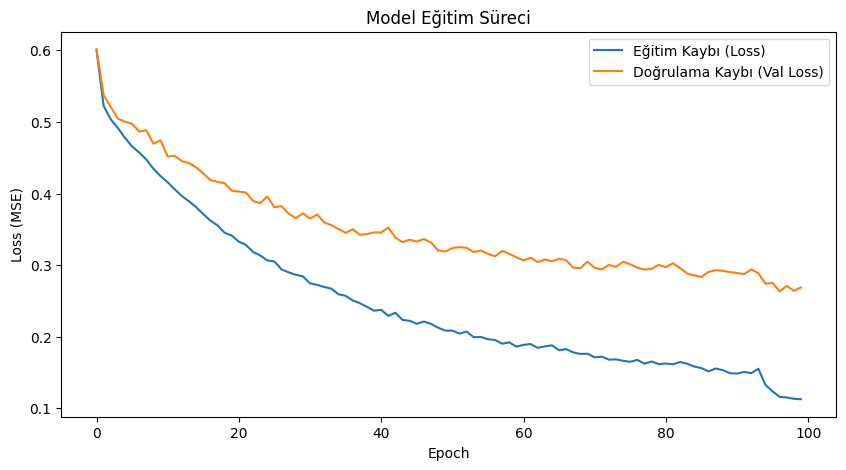

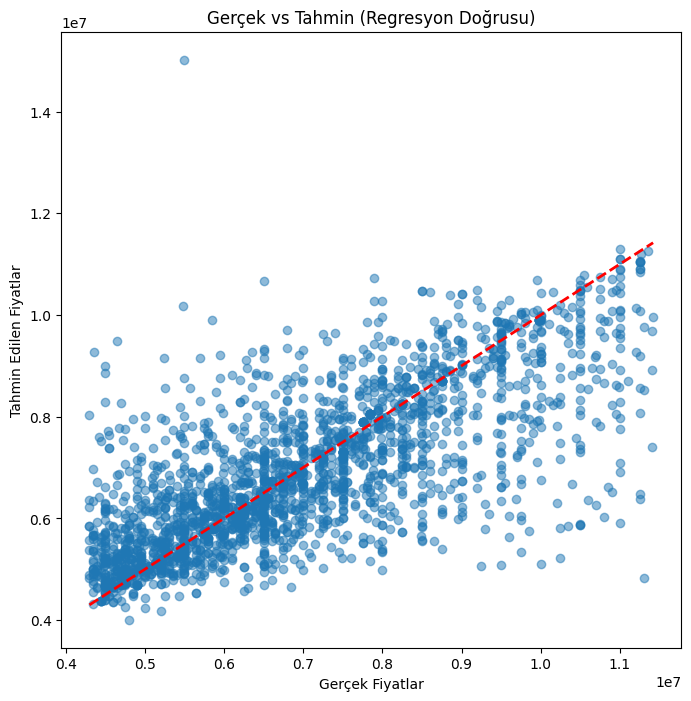

In [24]:
# Loss (Kayıp) grafiği
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Eğitim Kaybı (Loss)')
plt.plot(history.history['val_loss'], label='Doğrulama Kaybı (Val Loss)')
plt.title('Model Eğitim Süreci')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.show()

# Gerçek Fiyatlar vs Tahmin Edilen Fiyatlar Grafiği
plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Gerçek Fiyatlar')
plt.ylabel('Tahmin Edilen Fiyatlar')
plt.title('Gerçek vs Tahmin (Regresyon Doğrusu)')
plt.show()

In [25]:
import os
import joblib
import shutil
from pathlib import Path

# 1. Kaydedilecek yeni sıralı model klasörünü belirleme (model_0, model_1, model_2...)
models_base_dir = Path('../backend/ml-infra/models')
models_base_dir.mkdir(parents=True, exist_ok=True)

# Mevcut model_? klasörlerini tara ve en büyük numarayı bul
existing_models = [d.name for d in models_base_dir.iterdir() if d.is_dir() and d.name.startswith('model_')]
model_nums = []
for name in existing_models:
    try:
        model_nums.append(int(name.split('_')[1]))
    except ValueError:
        pass

next_model_num = max(model_nums) + 1 if model_nums else 0
new_model_dir = models_base_dir / f"model_{next_model_num}"
new_model_dir.mkdir(parents=True, exist_ok=True)
print(f"Yeni model dosyaları '{new_model_dir}' dizinine kaydediliyor...\n")

# 2. Keras modelini kaydetme (.keras formatı)
model.save(new_model_dir / 'model.keras')
print("- model.keras başarıyla kaydedildi.")

# 3. Scaler'ları kaydetme
joblib.dump(scaler_X, new_model_dir / 'scaler_X.pkl')
print("- scaler_X.pkl başarıyla kaydedildi.")

joblib.dump(scaler_y, new_model_dir / 'scaler_y.pkl')
print("- scaler_y.pkl başarıyla kaydedildi.")

# 4. Isıtma (One-Hot) kolon listesini kaydetme (Inference sırasında dinamik eşleme için)
isitma_cols = [col for col in X.columns if col.startswith('isitma_')]
joblib.dump(isitma_cols, new_model_dir / 'isitma_columns.pkl')
print("- isitma_columns.pkl başarıyla kaydedildi.")

# 5. Adım 4'te kaydettiğimiz target_encoder.pkl dosyasını yeni klasöre kopyalama
src_encoder = Path('../scraping/data/target_encoder.pkl')
dst_encoder = new_model_dir / 'target_encoder.pkl'

if src_encoder.exists():
    shutil.copy(src_encoder, dst_encoder)
    print("- target_encoder.pkl başarıyla kopyalandı.")
else:
    print("[UYARI] '../scraping/data/target_encoder.pkl' bulunamadı! Lütfen önce 4)Encoding.ipynb dosyasını çalıştırın.")

print(f"\n[BAŞARILI] Tüm entegrasyon dosyaları 'model_{next_model_num}' klasörüne eksiksiz kaydedildi!")

Yeni model dosyaları '..\backend\ml-infra\models\model_2' dizinine kaydediliyor...

- model.keras başarıyla kaydedildi.
- scaler_X.pkl başarıyla kaydedildi.
- scaler_y.pkl başarıyla kaydedildi.
- isitma_columns.pkl başarıyla kaydedildi.
- target_encoder.pkl başarıyla kopyalandı.

[BAŞARILI] Tüm entegrasyon dosyaları 'model_2' klasörüne eksiksiz kaydedildi!


# İyi Model 3

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, BatchNormalization, Activation
from tensorflow.keras.models import Model
from tensorflow.keras.regularizers import l2

# Girdi Boyutu (29 özellik)
input_dim = X_train_scaled.shape[1]

l2_reg = l2(1e-4)

# 1. GİRDİ KATMANI
inputs = Input(shape=(input_dim,))

x = Dense(256, kernel_initializer='he_normal', kernel_regularizer=l2_reg, use_bias=False)(inputs)
x = BatchNormalization()(x)
x = Activation('relu')(x)

x = Dense(256, kernel_initializer='he_normal', kernel_regularizer=l2_reg, use_bias=False)(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)

x = Dense(256, kernel_initializer='he_normal', kernel_regularizer=l2_reg, use_bias=False)(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)

x = Dense(256, kernel_initializer='he_normal', kernel_regularizer=l2_reg, use_bias=False)(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)

x = Dense(256, kernel_initializer='he_normal', kernel_regularizer=l2_reg, use_bias=False)(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)

x = Dense(128, kernel_initializer='he_normal', kernel_regularizer=l2_reg, use_bias=False)(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)

x = Dense(32, kernel_initializer='he_normal', kernel_regularizer=l2_reg, use_bias=False)(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)

outputs = Dense(1, kernel_initializer='he_normal')(x)

model = Model(inputs=inputs, outputs=outputs, name="Standard_Dense_No_Dropout")

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3), 
    loss='huber', 
    metrics=['mae']
)

model.summary()

Model: "Standard_Dense_No_Dropout"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 29)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 256)            │         7,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_24          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 256)            │        65,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_25          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 256)            │        65,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_26          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 256)            │        65,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_27          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 256)            │        65,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_28          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 128)            │        32,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_29          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 32)             │         4,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_30          │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 312,225 (1.19 MB)

 Trainable params: 309,345 (1.18 MB)

 Non-trainable params: 2,880 (11.25 KB)

In [28]:
# --- DENGELİ CALLBACKS ---
lr_reducer = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=1e-6, verbose=1)
early_stop = EarlyStopping(monitor='val_loss', patience=35, restore_best_weights=True, verbose=1)

# Eğitimi Başlatma
history = model.fit(
    X_train_scaled, y_train_scaled, 
    validation_data=(X_test_scaled, y_test_scaled),
    epochs=100, 
    batch_size=128, 
    callbacks=[early_stop, lr_reducer],
    verbose=1
)

Epoch 1/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - loss: 0.6772 - mae: 0.7534 - val_loss: 0.5553 - val_mae: 0.6046 - learning_rate: 0.0010
Epoch 2/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.5718 - mae: 0.6314 - val_loss: 0.5208 - val_mae: 0.5682 - learning_rate: 0.0010
Epoch 3/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.5465 - mae: 0.6073 - val_loss: 0.5112 - val_mae: 0.5643 - learning_rate: 0.0010
Epoch 4/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.5272 - mae: 0.5926 - val_loss: 0.4933 - val_mae: 0.5527 - learning_rate: 0.0010
Epoch 5/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.5125 - mae: 0.5841 - val_loss: 0.4836 - val_mae: 0.5485 - learning_rate: 0.0010
Epoch 6/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.4989 - mae: 0.5797 - val_loss: 0.4689 - val_mae: 0.5425 - learning_rate: 0.0010
Epoch 7/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.4867 - mae: 0.5768 - val_loss: 0.4575 - val_mae: 0.5419 - learning_rate: 0.0010
Epoch 

In [29]:
# Modelden tahmin alma (Bu tahminler ölçeklenmiş değerlerdir)
y_pred_scaled = model.predict(X_test_scaled)

# Ölçeklenmiş tahminleri ve test değerlerini gerçek fiyat aralığına geri çevirme (Inverse Transform)
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_test_real = scaler_y.inverse_transform(y_test_scaled)

# R2 ve diğer hata metrikleri gerçek fiyatlar üzerinden hesaplanıyor
r2 = r2_score(y_test_real, y_pred)
mae = mean_absolute_error(y_test_real, y_pred)
rmse = np.sqrt(mean_squared_error(y_test_real, y_pred))

print(f"Test R2 Skoru: {r2:.4f}")
print(f"Test Ortalama Mutlak Hata (MAE): {mae:,.2f} TL")
print(f"Test Kök Ortalama Kare Hata (RMSE): {rmse:,.2f} TL")

38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
Test R2 Skoru: 0.5440
Test Ortalama Mutlak Hata (MAE): 879,488.98 TL
Test Kök Ortalama Kare Hata (RMSE): 1,189,186.59 TL


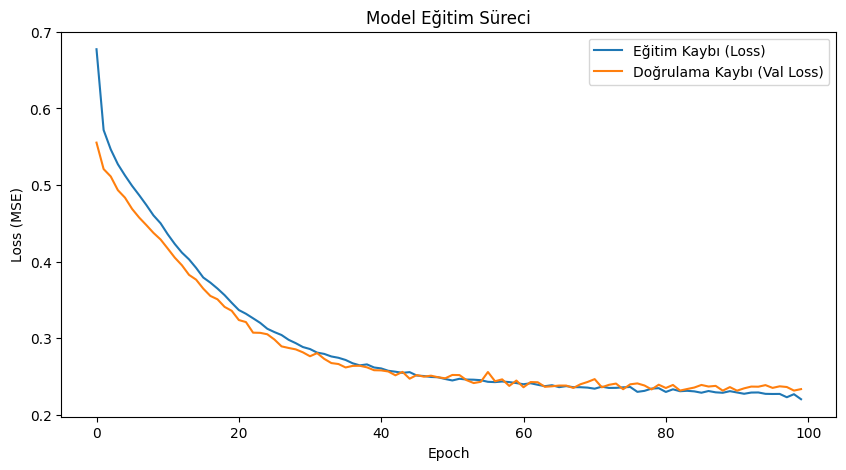

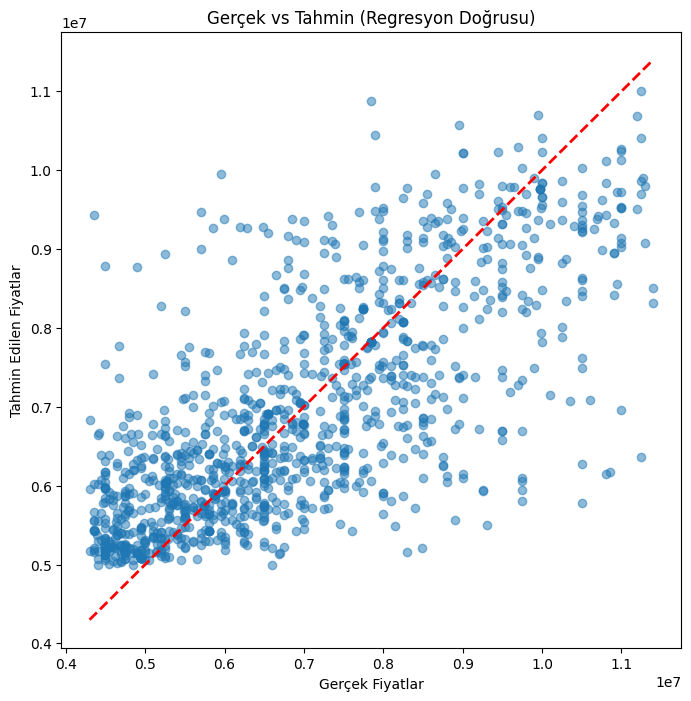

In [30]:
# Loss (Kayıp) grafiği
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Eğitim Kaybı (Loss)')
plt.plot(history.history['val_loss'], label='Doğrulama Kaybı (Val Loss)')
plt.title('Model Eğitim Süreci')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.show()

# Gerçek Fiyatlar vs Tahmin Edilen Fiyatlar Grafiği
plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Gerçek Fiyatlar')
plt.ylabel('Tahmin Edilen Fiyatlar')
plt.title('Gerçek vs Tahmin (Regresyon Doğrusu)')
plt.show()

In [31]:
import os
import joblib
import shutil
from pathlib import Path

# 1. Kaydedilecek yeni sıralı model klasörünü belirleme (model_0, model_1, model_2...)
models_base_dir = Path('../backend/ml-infra/models')
models_base_dir.mkdir(parents=True, exist_ok=True)

# Mevcut model_? klasörlerini tara ve en büyük numarayı bul
existing_models = [d.name for d in models_base_dir.iterdir() if d.is_dir() and d.name.startswith('model_')]
model_nums = []
for name in existing_models:
    try:
        model_nums.append(int(name.split('_')[1]))
    except ValueError:
        pass

next_model_num = max(model_nums) + 1 if model_nums else 0
new_model_dir = models_base_dir / f"model_{next_model_num}"
new_model_dir.mkdir(parents=True, exist_ok=True)
print(f"Yeni model dosyaları '{new_model_dir}' dizinine kaydediliyor...\n")

# 2. Keras modelini kaydetme (.keras formatı)
model.save(new_model_dir / 'model.keras')
print("- model.keras başarıyla kaydedildi.")

# 3. Scaler'ları kaydetme
joblib.dump(scaler_X, new_model_dir / 'scaler_X.pkl')
print("- scaler_X.pkl başarıyla kaydedildi.")

joblib.dump(scaler_y, new_model_dir / 'scaler_y.pkl')
print("- scaler_y.pkl başarıyla kaydedildi.")

# 4. Isıtma (One-Hot) kolon listesini kaydetme (Inference sırasında dinamik eşleme için)
isitma_cols = [col for col in X.columns if col.startswith('isitma_')]
joblib.dump(isitma_cols, new_model_dir / 'isitma_columns.pkl')
print("- isitma_columns.pkl başarıyla kaydedildi.")

# 5. Adım 4'te kaydettiğimiz target_encoder.pkl dosyasını yeni klasöre kopyalama
src_encoder = Path('../scraping/data/target_encoder.pkl')
dst_encoder = new_model_dir / 'target_encoder.pkl'

if src_encoder.exists():
    shutil.copy(src_encoder, dst_encoder)
    print("- target_encoder.pkl başarıyla kopyalandı.")
else:
    print("[UYARI] '../scraping/data/target_encoder.pkl' bulunamadı! Lütfen önce 4)Encoding.ipynb dosyasını çalıştırın.")

print(f"\n[BAŞARILI] Tüm entegrasyon dosyaları 'model_{next_model_num}' klasörüne eksiksiz kaydedildi!")

Yeni model dosyaları '..\backend\ml-infra\models\model_2' dizinine kaydediliyor...

- model.keras başarıyla kaydedildi.
- scaler_X.pkl başarıyla kaydedildi.
- scaler_y.pkl başarıyla kaydedildi.
- isitma_columns.pkl başarıyla kaydedildi.
[UYARI] '../scraping/data/target_encoder.pkl' bulunamadı! Lütfen önce 4)Encoding.ipynb dosyasını çalıştırın.

[BAŞARILI] Tüm entegrasyon dosyaları 'model_2' klasörüne eksiksiz kaydedildi!
